In [12]:
from Dataset.DataSetLoaders import ChessDataset
import ChessLens

import cv2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

from tqdm import tqdm

2142

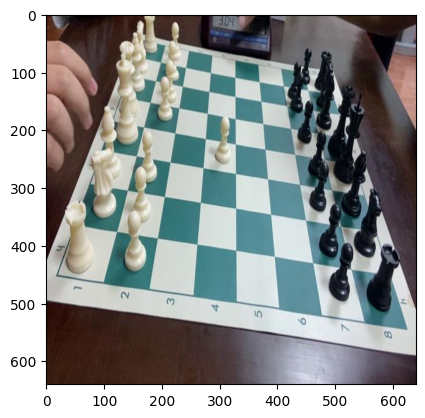

In [26]:
ds = ChessDataset.GameDataset(
    config={
        "img_size": (640,640),
        # "include_only": "valid;occlusion"
        "include_only": "valid"
    }
)

img,y = ds[3]

plt.imshow(img.permute(1,2,0));
# y["image_path"]
len(ds)

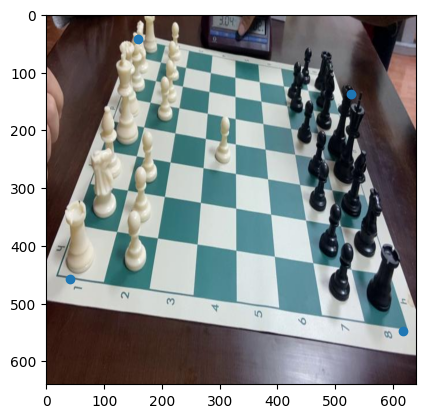

In [14]:
img_obj = ChessLens.ChessLensImage(img, "cnn")

img_obj.detect_board()
warped, M = img_obj.warp()

plt.imshow(img.permute(1,2,0));
plt.scatter(img_obj.board_detection[:,0], img_obj.board_detection[:,1]);

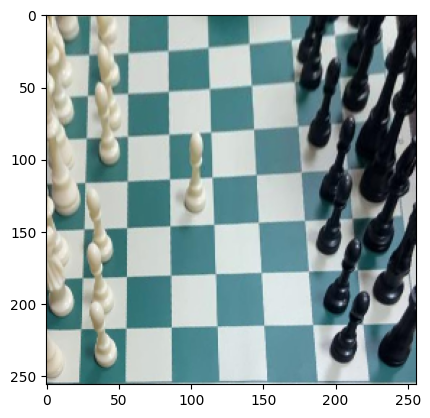

In [15]:
plt.imshow(warped);

In [16]:
warps = []

In [17]:
for i in tqdm(range(len(ds))):
    try:
        img, y = ds[i]
        img = ChessLens.ChessLensImage(img)
        img.detect_board()
        warped, _ = img.warp()
        warps.append(warped)
    except:
        pass

100%|██████████| 2477/2477 [04:54<00:00,  8.42it/s]


In [18]:
warps = np.array(warps)

In [ ]:
with open("tmp.npy", "wb") as f:
    np.save(f, warps)

In [6]:
with open("tmp.npy", "rb") as f:
    warps = np.load(f)

In [7]:
i = 0

NameError: name 'errs' is not defined

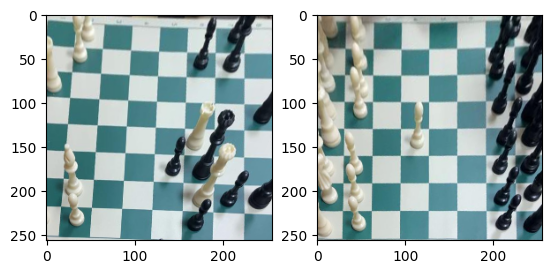

In [8]:
plt.subplot(1,2,1)
plt.imshow(warps[i-1]);
plt.subplot(1,2,2)
plt.imshow(warps[i]);

print(i, errs[i])

i += 1

In [41]:
hists = []

bins = 8
for i in range(warps.shape[0]):
    hist_r, _ = np.histogram(warps[i,:,:,0].ravel(), bins=bins, range=[0,256])
    hist_g, _ = np.histogram(warps[i,:,:,1].ravel(), bins=bins, range=[0,256])
    hist_b, _ = np.histogram(warps[i,:,:,2].ravel(), bins=bins, range=[0,256])

    hist = np.concat([hist_r, hist_g, hist_b], axis=0)
    hists.append(hist)

In [42]:
hists = np.array(hists) / (256*256)

hists.shape

(2142, 24)

In [82]:
errs = [0]

for i in range(1, warps.shape[0]):
    # errs.append(((warps[i] - warps[i-1])**2).mean().item())
    errs.append(((hists[i] - hists[i-1])**2).mean().item())

errs = np.array(errs)

errs[0] = errs[1:].mean()

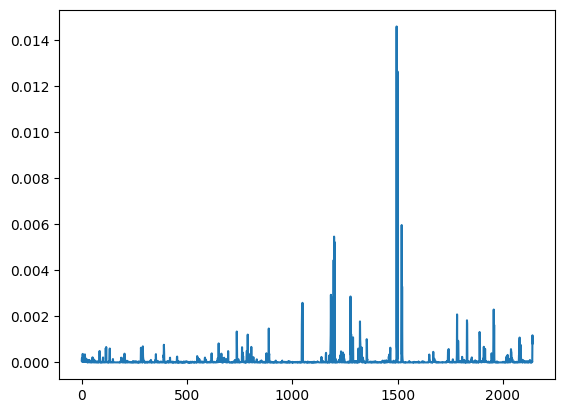

In [83]:
plt.plot(np.arange(len(errs)), errs);

In [84]:
with open("tmp_labels.npy", "rb") as f:
    lbls = np.load(f)

In [85]:
new_moves = np.concat([np.zeros(1, dtype=np.int32), (lbls[1:] != lbls[:-1]).astype(np.int32)], axis=0)

new_moves.shape, lbls.shape

((2142,), (2142,))

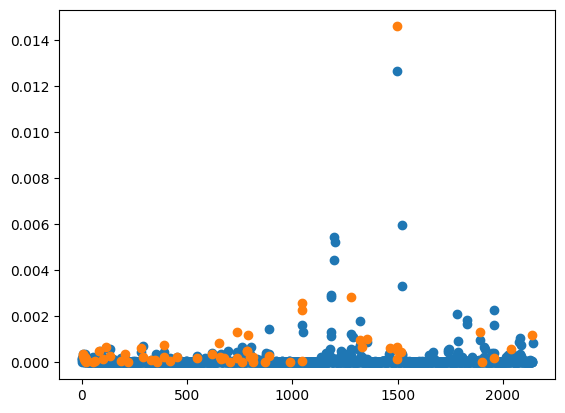

In [86]:
plt.scatter(np.arange(len(errs))[new_moves==0], errs[new_moves==0]);
plt.scatter(np.arange(len(errs))[new_moves==1], errs[new_moves==1]);

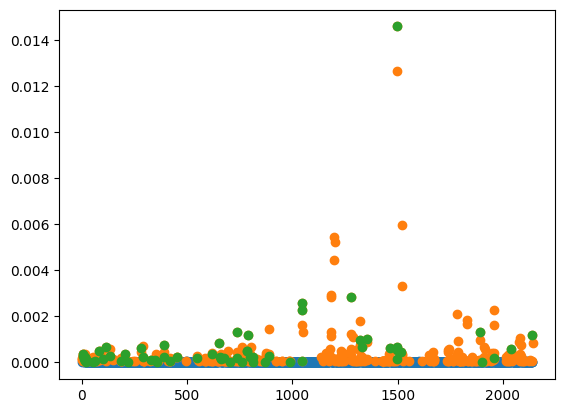

In [87]:
t = -10

plt.scatter(np.arange(len(errs))[np.log(errs)<t], errs[np.log(errs)<t]);
plt.scatter(np.arange(len(errs))[np.log(errs)>=t], errs[np.log(errs)>=t]);
plt.scatter(np.arange(len(errs))[new_moves==1], errs[new_moves==1]);

In [88]:
errs[new_moves==1].mean(), errs[new_moves==1].min(), errs[new_moves==1].max()

(np.float64(0.0006907798901752188),
 np.float64(7.11375226577123e-06),
 np.float64(0.014592540896652887))

In [89]:
errs[new_moves==0].mean(), errs[new_moves==0].min(), errs[new_moves==0].max()

(np.float64(6.937010238418763e-05),
 np.float64(3.1670788303017616e-07),
 np.float64(0.012640549296823641))

In [90]:
errs = -np.log(errs)

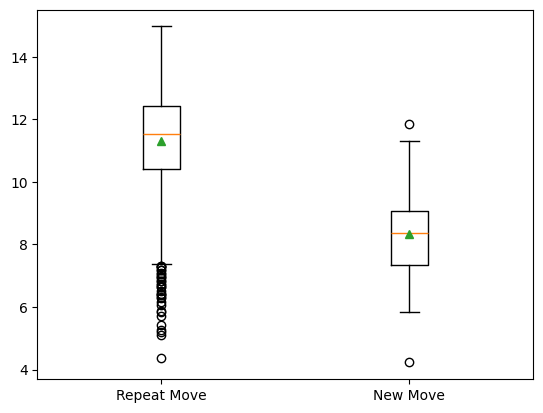

In [92]:
plt.boxplot([errs[new_moves==0], errs[new_moves==1]], tick_labels=["Repeat Move", "New Move"], showmeans=True);

In [93]:
(errs<10).sum(), len(errs)

(np.int64(405), 2142)

In [98]:
vals_kept, counts_kept = np.unique(lbls[errs<10], return_counts=True)

vals_kept.shape, vals_kept, counts_kept

((64,),
 array([ 1,  3,  4,  5,  7,  8,  9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 68, 69, 70, 71], dtype=int8),
 array([ 3,  3,  2,  2,  2,  2,  1,  7,  2,  3,  3,  4,  2,  5,  6,  4,  3,  3,  7,  2,  3,  2,  1,  5,  2,  4, 13, 10,  5,  3,  1,  6, 11,  2,  1,  8,  4,  1,  3,  6,  4,  1,  5,  3,  9,  1,  1,  1, 39, 17,  5,  4, 24,  5,  1,  1,  1,  2, 64,  5, 13, 14, 26,  2]))

In [99]:
vals, counts = np.unique(lbls, return_counts=True)

vals.shape, vals, counts

((64,),
 array([ 1,  3,  4,  5,  7,  8,  9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 68, 69, 70, 71], dtype=int8),
 array([  4,   3,   4,   3,   2,   5,   1,  30,  10,  22,  16,  16,  16,  53,  18,  15,  63,  10,  37,  22,   9,  30,   1,  30,  32,  97,  67,  34,   7,   4,   1,  14,  27,  32,   1,  26,  22,   1,   3,  12,  11,   4,  53,  21, 102,  55,   1,   1, 228,  46,   7,  24, 112,  30,   1,   1,   1,  20, 371,  12,  54,  83,
        102,   2]))

In [100]:
dropped_portions = (counts - counts_kept) / counts

In [112]:
np.stack([counts_kept, counts-counts_kept], axis=1)[dropped_portions > .6].transpose(1,0)

array([[  7,   2,   3,   3,   4,   2,   5,   6,   4,   3,   3,   7,   2,   3,   2,   5,   2,   4,  13,  10,   2,   8,   4,   4,   1,   5,   3,   9,   1,  39,  17,   4,  24,   5,   2,  64,  13,  14,  26],
       [ 23,   8,  19,  13,  12,  14,  48,  12,  11,  60,   7,  30,  20,   6,  28,  25,  30,  93,  54,  24,  30,  18,  18,   7,   3,  48,  18,  93,  54, 189,  29,  20,  88,  25,  18, 307,  41,  69,  76]])

In [131]:
frames_idx = np.arange(errs.shape[0])[errs<10]

time_diffs = ((frames_idx[1:] - frames_idx[:-1]) * 500)

time_diffs.mean(), time_diffs.min(), time_diffs.max()

(np.float64(2649.7524752475247), np.int64(500), np.int64(44500))

(array([        343,          29,          12,          12,           2,           0,           5,           0,           0,           1]),
 array([          1,         9.8,        18.6,        27.4,        36.2,          45,        53.8,        62.6,        71.4,        80.2,          89]),
 <BarContainer object of 10 artists>)

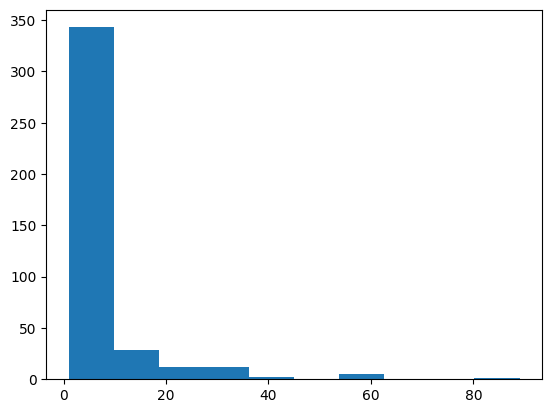

In [135]:
plt.hist(time_diffs/500)

In [136]:
(time_diffs==500).sum(), time_diffs.shape

(np.int64(230), (404,))

# Using WakeupModule

In [19]:
from WakeupDetection.WakeupModule import WakeupModule
import numpy as np
from tqdm import tqdm

In [20]:
module = WakeupModule()

In [3]:
with open("tmp.npy", "rb") as f:
    warps = np.load(f)

In [21]:
res = []

for i in tqdm(range(warps.shape[0])):
    res.append(module.is_wakeup(warps[i]))

100%|██████████| 2474/2474 [00:06<00:00, 409.60it/s]


In [25]:
res[:10], len(res), sum(res)

([True, True, True, True, True, True, True, True, True, True], 2474, 653)

In [24]:
(np.arange(2474)[res])

array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,   11,   12,   13,   14,   15,   16,   17,   20,   21,   22,   23,   25,   26,   27,   28,   29,   30,   31,   32,   33,   34,   35,   36,   46,   47,   48,   49,   50,   51,   52,   53,   54,   57,   58,   59,   60,   67,   68,   72,   86,   88,
         89,   91,   97,  101,  102,  111,  123,  124,  125,  126,  127,  129,  142,  144,  145,  146,  159,  160,  161,  162,  163,  164,  179,  180,  181,  195,  196,  232,  233,  234,  235,  237,  238,  239,  249,  250,  255,  258,  259,  269,  270,  273,  274,  275,  276,  300,  311,  329,  330,  349,  356,  371,
        372,  373,  381,  382,  383,  384,  385,  386,  387,  388,  389,  416,  421,  422,  423,  424,  425,  446,  447,  448,  449,  450,  451,  459,  460,  461,  462,  463,  464,  465,  493,  494,  496,  497,  498,  499,  500,  520,  526,  528,  529,  530,  531,  532,  533,  534,  567,  568,  609,  663,  664,  665,
        666,  669,  674,  675,  700,  701, 